In [1]:
from math import exp
import copy
import numpy as np
import matplotlib.pyplot as plt
from operator import attrgetter

## Nonstationary Bandit Environment

In [2]:
# Gaussian Process with Radial Basis Function Kernel
def rbf_kernel(x1, x2, variance = 1):
    return exp(-1 * ((x1-x2) ** 2) / (2*variance))

def gram_matrix(xs,var):
    return [[rbf_kernel(x1,x2,variance=var) for x2 in xs] for x1 in xs]

def generate_mean_rewards(n_arms=5,smoothness=1):
    xs = np.arange(0, 5, 0.025)
    mean = [0 for x in xs]
    gram = gram_matrix(xs, var=smoothness)
        
    all_mean_rewards = []
    for i in range(n_arms):
        mus = np.random.multivariate_normal(mean, gram)
        all_mean_rewards.append(mus)
    return np.vstack(all_mean_rewards)

def generate_rewards(mean_rewards, noise_var=1):
    rewards = mean_rewards + np.random.normal(0,np.sqrt(noise_var),size=mean_rewards.shape)
    return rewards

## Examining the Nonstationary Environment

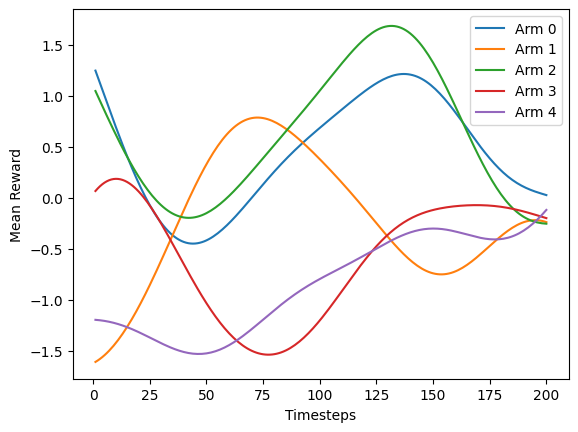

In [3]:
mean_rewards = generate_mean_rewards(smoothness=1)
plt.figure()
for k in range(len(mean_rewards)):
    plt.plot(np.arange(1,len(mean_rewards[k])+1), mean_rewards[k], label='Arm {}'.format(k))
plt.ylabel('Mean Reward')
plt.xlabel('Timesteps')
plt.legend()
plt.show()

## Generating Rewards

In [4]:
rewards = generate_rewards(mean_rewards, noise_var=1)

## Solutions

### (b)

In [5]:
class Arm:
    def __init__(self, index, mu_t_a, sigma):
        self.index = index
        self.numplays = 0.0
        self.mu_t_a = mu_t_a
        self.sigma = sigma
        self.totrew = 0.0
        self.avgrew = 0.0

    def sample(self, t):
        return np.random.normal(self.mu_t_a[t], np.sqrt(self.sigma))

    def update(self, rew):
        self.numplays += 1
        self.totrew += rew
        self.avgrew = self.totrew / self.numplays

    def play(self, t):
        rew = self.sample(t)
        self.update(rew)
        return rew

def GetArms(K, mu_t, noise_var):
    arms = []
    for i in range(K):
        arms.append(Arm(i, mu_t[i], noise_var))
    return arms

In [6]:
# might be worth changing the formula for cb
def UpdateCBs(arm, T, K):
    cb = np.sqrt(2 * arm.sigma * (np.log(T * K)) / arm.numplays)
    arm.ucb = arm.avgrew + cb
    arm.lcb = arm.avgrew - cb

def UpperConfidenceBound(arms, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)

    for arm in arms:
        rew[t] = arm.play(t)
        reg[t] = max(arm.mu_t_a[t] for arm in arms) - arm.mu_t_a[t]
        UpdateCBs(arm, T, K)
        t += 1
        if t == T:
            break

    while t < T:
        arm = max(arms, key=attrgetter('ucb'))
        rew[t] = arm.play(t)
        reg[t] = max(arm.mu_t_a[t] for arm in arms) - arm.mu_t_a[t]
        UpdateCBs(arm, T, K)
        t += 1

    return rew, reg

In [7]:
def ThompsonSampling_Gaussian(arms, priors, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)
    Gaussian_params = np.zeros((T, K, 2))

    posterior = 1.0*priors

    while t < T:
        thompson_samples = np.zeros(K)
        for arm in arms:
            thompson_samples[arm.index] = np.random.normal(posterior[arm.index, 0],
                                                           np.sqrt(posterior[arm.index, 1]))
        
        best_index = np.argmax(thompson_samples)
        arm = arms[best_index]
        rew[t] = arm.play(t)
        reg[t] = max([arm.mu_t_a[t] for arm in arms]) - arm.mu_t_a[t]

        mu_0 = posterior[best_index, 0]
        sigma2_0 = posterior[best_index, 1]
        sigma2 = arm.sigma
        posterior[best_index] = [((mu_0 / sigma2_0) + (rew[t] / sigma2)) / ((1 / sigma2) + (1 / sigma2_0)),
                                  1 / ((1 / sigma2) + (1 / sigma2_0))]

        Gaussian_params[t] = posterior
        t += 1

    return rew, reg, Gaussian_params

In [8]:
def UniformSampling(arms, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)

    while t < T:
        arm = np.random.choice(arms)
        rew[t] = arm.play(t)
        reg[t] = max(arm.mu_t_a[t] for arm in arms) - arm.mu_t_a[t]
        
        t += 1

    return rew, reg

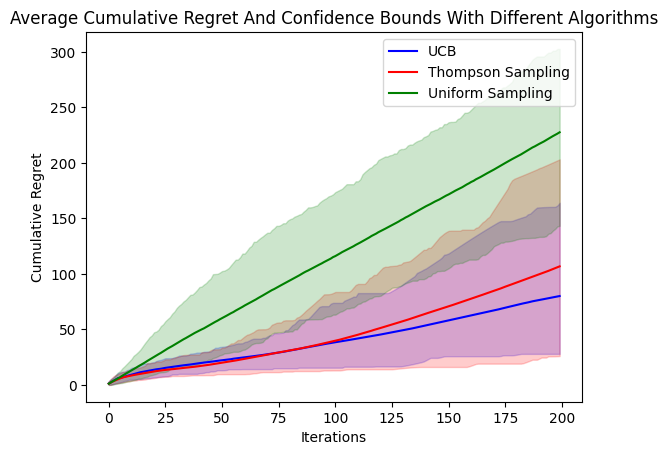

In [9]:
K, T, noise_var = 5, 200, 1
n_sim = 100

#array = np.tile(np.arange(0.1, 1.1, 0.1), (1000, 1)).T

regrets = np.zeros((n_sim, T))

for sim in range(n_sim):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, noise_var)
    for arm in bandits_env:
        setattr(arm, 'ucb', 1000.0)
        setattr(arm, 'lcb', -1000.0)
    regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])

mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[94]
CB5 = sorted_regrets[4]
plt.plot(mean_regrets, label='UCB', color='b')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='b')

regrets = np.zeros((n_sim, T))
standard_priors = np.tile(np.array([0, 10]), (K, 1))

for sim in range(n_sim):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, noise_var)
    regrets[sim] = np.cumsum(ThompsonSampling_Gaussian(bandits_env, standard_priors, T)[1])

mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[94]
CB5 = sorted_regrets[4]
plt.plot(mean_regrets, label='Thompson Sampling', color='r')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='r')

regrets = np.zeros((n_sim, T))

for sim in range(n_sim):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, noise_var)
    regrets[sim] = np.cumsum(UniformSampling(bandits_env, T)[1])

mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[94]
CB5 = sorted_regrets[4]
plt.plot(mean_regrets, label='Uniform Sampling', color='g')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='g')

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Average Cumulative Regret And Confidence Bounds With Different Algorithms')
plt.show()

### (c)

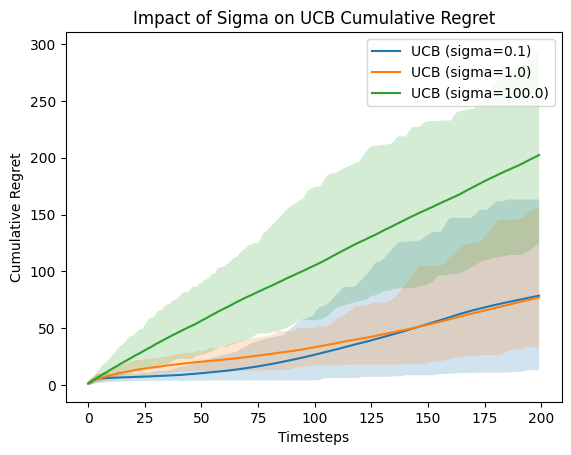

In [10]:
noise_vars = [0.1, 1.0, 100.0]

for noise_var in noise_vars:
    regrets = np.zeros((n_sim, T))

    for sim in range(n_sim):
        mean_rewards = generate_mean_rewards()
        bandits_env = GetArms(K, mean_rewards, noise_var)
        for arm in bandits_env:
            setattr(arm, 'ucb', 1000.0)
            setattr(arm, 'lcb', -1000.0)
        regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])

    mean_regrets = np.mean(regrets, axis=0)
    sorted_regrets = np.sort(regrets, axis=0)
    CB95 = sorted_regrets[94]
    CB5 = sorted_regrets[4]

    # Plotting the results for the current sigma
    plt.plot(mean_regrets, label=f'UCB (sigma={noise_var})')
    plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2)

plt.xlabel('Timesteps')
plt.ylabel('Cumulative Regret')
plt.title('Impact of Sigma on UCB Cumulative Regret')
plt.legend()
plt.show()

### (e)

In [11]:
def Rexp3(arms, gamma, delta_T, T):
    rew = np.zeros(T)  # Rewards array to track rewards over time
    reg = np.zeros(T)  # Regret array to track regret over time
    j = 1  # Batch index
    K = len(arms)  # Number of arms
    

    # Loop while batch index j is within the ceiling of T / delta_T
    while j <= np.ceil(T / delta_T):
        tau = (j - 1) * delta_T  # Set tau for current batch
        weights = np.ones(K)  # Initialize weights

        for t in range(tau + 1, min(T, tau + delta_T) + 1):
            # Calculate probabilities
            p = (1 - gamma) * (weights / np.sum(weights)) + (gamma / K)
            #print(p)
            arm_index = np.random.choice(K, p=p)  # Draw an arm according to probabilities
            arm = arms[arm_index]
            #print(arm_index)
        
            # Receive reward
            reward = arm.play(t - 1)  # Use t - 1 for zero-based indexing
            #reward = arm.mu_t_a[t-1]
            rew[t - 1] = reward  # Update reward array with received reward at time t

            # Calculate regret at this time step
            reg[t - 1] = max(arms[k].mu_t_a[t - 1] for k in range(K)) - arm.mu_t_a[t - 1]
            #print(max(arms[k].mu_t_a[t - 1] for k in range(K)) - arm.mu_t_a[t - 1])

            # Adjust the received reward for weight updates
            adjusted_reward = reward / p[arm_index]  # Adjust reward by the selection probability
        
            # Update weights for each arm
            for k in range(K):
                if k == arm_index:
                    weights[k] *= np.exp(gamma * adjusted_reward / K)  # Update weight for chosen arm
                else:
                    weights[k] *= 1  # No change for non-chosen arms

        j += 1  # Move to the next batch

    return rew, reg

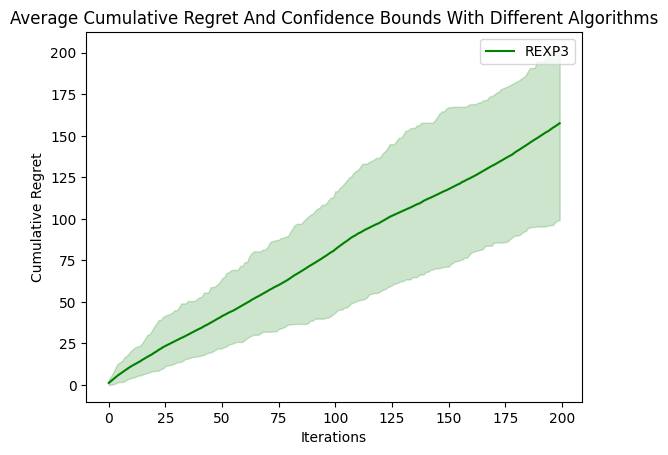

In [18]:
K, T, noise_var = 5, 200, 1
n_sim = 100

# Add parameters for REXP3
gamma = 0.5  # Exploration parameter
delta_T = 100  # Batch size

# Running REXP3
regrets_rexp3 = np.zeros((n_sim, T))

for sim in range(n_sim):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, noise_var)
    regrets_rexp3[sim] = np.cumsum(Rexp3(bandits_env, gamma, delta_T, T)[1])

# Calculate and plot mean regrets for REXP3
mean_regrets_rexp3 = np.mean(regrets_rexp3, axis=0)
sorted_regrets_rexp3 = np.sort(regrets_rexp3, axis=0)
CB95_rexp3 = sorted_regrets_rexp3[94]
CB5_rexp3 = sorted_regrets_rexp3[4]

plt.plot(mean_regrets_rexp3, label='REXP3', color='g')
plt.fill_between(np.arange(T), CB5_rexp3, CB95_rexp3, alpha=0.2, color='g')

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Average Cumulative Regret And Confidence Bounds With Different Algorithms')
plt.show()